In [142]:
from utils.analyse_results import GraphsTraining, Results, load_all_pickles, plot_time_bands, Graphs
import pandas as pd
train_info = GraphsTraining()
import numpy as np

### Load Pyomo results

In [143]:
results_pyomo = load_all_pickles("results/study_ho_reg/pyomo_ho_241225", recursive=False)
pyomo_df_prev = Results.flatten_convergence_data(results_pyomo, key_list=["system", "reg", "tol"], model_type="pyomo")

results_pyomo = load_all_pickles("results/reg_study/pyomo_ho_reg_study", recursive=False)
pyomo_df_ho = Results.flatten_convergence_data(results_pyomo, key_list=["reg"], model_type="pyomo")


results_pyomo = load_all_pickles("results/reg_study/pyomo_vdp_reg_study", recursive=False)
pyomo_df_vdp = Results.flatten_convergence_data(results_pyomo, key_list=["reg"], model_type="pyomo")

# results_reg_norm_df = results_reg_norm_df.dropna()
# results_reg_norm_df["n_neurons"] = results_reg_norm_df["system"].apply(lambda x: x[1])

Loaded results/study_ho_reg/pyomo_ho_241225/1169419491_2025-12-24_17-10.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/1333561404_2025-12-24_12-07.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/1385356387_2025-12-24_17-09.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/1755179491_2025-12-24_17-08.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2024901110_2025-12-24_11-24.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2100520546_2025-12-24_11-41.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2513813645_2025-12-24_12-34.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2673879830_2025-12-24_13-54.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/290969297_2025-12-24_14-39.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/2939113681_2025-12-24_11-18.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/3153811625_2025-12-24_14-22.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/3212649863_2025-12-24_13-24.pkl
Loaded results/study_ho_reg/pyomo_ho_241225/3223672450_2025-12-24_15-04.pkl
Loaded result

In [144]:
# Graphs.plot_boxplots_custom(pyomo_train['mse_train_coll'], pyomo_train['mse_train_coll'], pyomo_train.x_labels, 
#             '',     
#               'MSE Train', color_labels=["Pyomo", "JAX"],
#               x_label = "Layer Width",
#               figsize=(10, 6),
#               label_fontsize=20,
#               tick_fontsize=18,
#               legend_fontsize=20,
#               title_fontsize=20,
#               legend_bbox_y=-0.02,
#               legend_ncol=2,
#               y_log = True
#               )

### Load JAX results

In [145]:
results = load_all_pickles("results/reg_study/jax_ho_reg_study", recursive=True)
jax_results_ho = Results.flatten_convergence_data(results, model_type="jax", key_list = ["penalty_lambda_reg"])

results = load_all_pickles("results/reg_study/jax_vdp_reg_study", recursive=True)
jax_results_vdp = Results.flatten_convergence_data(results, model_type="jax", key_list = ["penalty_lambda_reg"])

jax_results_ho = jax_results_ho.groupby(["seed", "penalty_lambda_reg"]).apply(lambda x: x.sort_values("time_elapsed").iloc[1]).reset_index(drop=True)
jax_results_vdp = jax_results_vdp.groupby(["seed", "penalty_lambda_reg"]).apply(lambda x: x.sort_values("time_elapsed").iloc[-3]).reset_index(drop=True)

Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/1121970396_2026-02-21_23-45.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/2356637466_2026-02-21_23-46.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/2523950856_2026-02-21_23-38.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/2791000513_2026-02-21_23-45.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/3603998239_2026-02-21_23-44.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/4099584551_2026-02-21_23-40.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/4125270533_2026-02-21_23-42.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/78750204_2026-02-21_23-41.pkl
Loaded results/reg_study/jax_ho_reg_study/jax_ho_w2-32-2_1000_5000_210226_2338/924555503_2026-02-21_23-43.pkl
Load

/var/folders/2v/gfm3z1tn5fj8zss_r9hrgnv80000gn/T/ipykernel_16429/3766678079.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  jax_results_ho = jax_results_ho.groupby(["seed", "penalty_lambda_reg"]).apply(lambda x: x.sort_values("time_elapsed").iloc[1]).reset_index(drop=True)
/var/folders/2v/gfm3z1tn5fj8zss_r9hrgnv80000gn/T/ipykernel_16429/3766678079.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  jax_

## prepare the data

In [146]:
pyomo_df_ho.head(1)

,reg,time_elapsed,mse_train,mse_test,direct_model_pred,odeint_pred,odeint_pred_test,mse_train_coll,mse_test_coll,termination,seed
0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [147]:
pyomo_train_ho = Results.prep_for_boxplots(pyomo_df_ho,  'reg',  'mse_train_coll')
pyomo_train_vdp = Results.prep_for_boxplots(pyomo_df_vdp,  'reg',  'mse_train_coll')

jax_train_ho = Results.prep_for_boxplots(jax_results_ho,  'penalty_lambda_reg',  'mse_train')
jax_train_vdp = Results.prep_for_boxplots(jax_results_vdp,  'penalty_lambda_reg',  'mse_train')

pyomo_test_ho = Results.prep_for_boxplots(pyomo_df_ho,  'reg',  'mse_test_coll')
pyomo_test_vdp = Results.prep_for_boxplots(pyomo_df_vdp,  'reg',  'mse_test_coll')

jax_test_ho = Results.prep_for_boxplots(jax_results_ho,  'penalty_lambda_reg',  'mse_test')
jax_test_vdp = Results.prep_for_boxplots(jax_results_vdp,  'penalty_lambda_reg',  'mse_test')


jax_time_ho = Results.prep_for_boxplots(jax_results_ho,  'penalty_lambda_reg',  'time_elapsed')
jax_time_vdp = Results.prep_for_boxplots(jax_results_vdp,  'penalty_lambda_reg',  'time_elapsed')
pyomo_time_ho = Results.prep_for_boxplots(pyomo_df_ho,  'reg',  'time_elapsed')
pyomo_time_vdp = Results.prep_for_boxplots(pyomo_df_vdp,  'reg',  'time_elapsed')

## Harmonic Oschillator

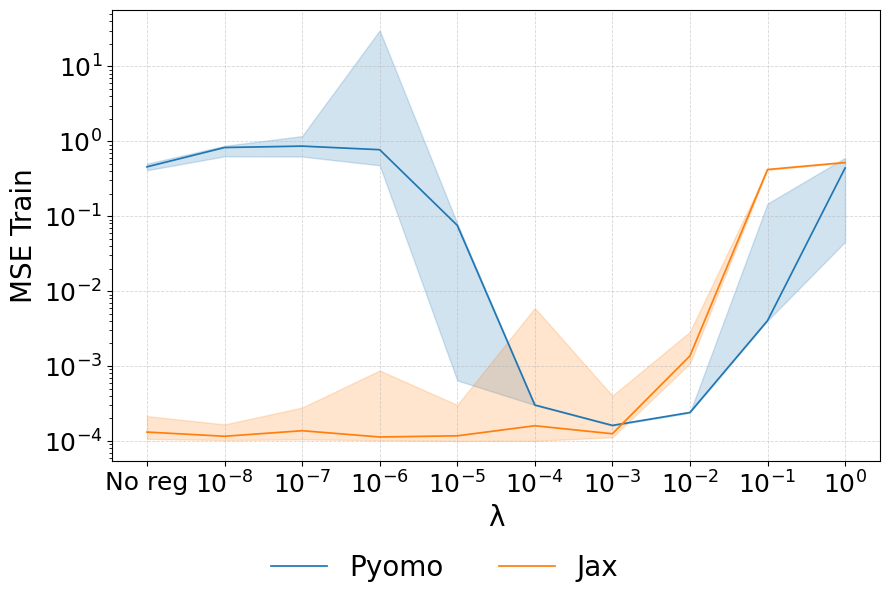

<Axes: xlabel='λ', ylabel='MSE Train'>

In [148]:
exponents = ["No reg", -8, -7, -6, -5, -4, -3, -2, -1, 0] 
x_ticklabels = [fr"$10^{{{p}}}$" if type(p) != str else p for p in exponents]

Graphs.plot_lines_ci_from_lists(
    pyomo_train_ho['mse_train_coll'],
    # pyomo_test_ho['mse_test_coll'],
    jax_train_ho['mse_train'],
    pyomo_train_ho.x_labels,
    title="",
    ylabel="MSE Train",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(9, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(5,95),
    alpha_band=0.2,
    line_width=1.25,
    y_log=True,               # default; keeps 10^k ticks
    y_log_locator_base=10,    # default; uses LogLocator
    y_log_mathtext=True,      # default; renders 10^k
    # center = 'mean',
    x_ticklabels=x_ticklabels
)


In [149]:
pyomo_time_ho

,time_elapsed,x_labels
0,"[nan, nan, nan, nan, nan, nan, nan, 815.720335...",0.000000e+00
1,"[nan, 109.9121961593628, 255.35965609550476, n...",1.000000e-08
2,"[108.1129961013794, 175.86390590667725, 145.13...",1.000000e-07
3,"[42.17699909210205, 59.45772624015808, nan, 50...",1.000000e-06
4,"[15.725159883499146, 14.117047786712646, 13.88...",1.000000e-05
5,"[7.825376987457275, 3.962639808654785, 5.22515...",1.000000e-04
6,"[5.62390398979187, 2.475216865539551, 6.571851...",1.000000e-03
7,"[5.243090867996216, 9.028359174728394, 8.14655...",1.000000e-02
8,"[32.00325393676758, 118.43055605888367, 30.701...",1.000000e-01
9,"[nan, 31.306530952453613, 386.3642358779907, 2...",1.000000e+00


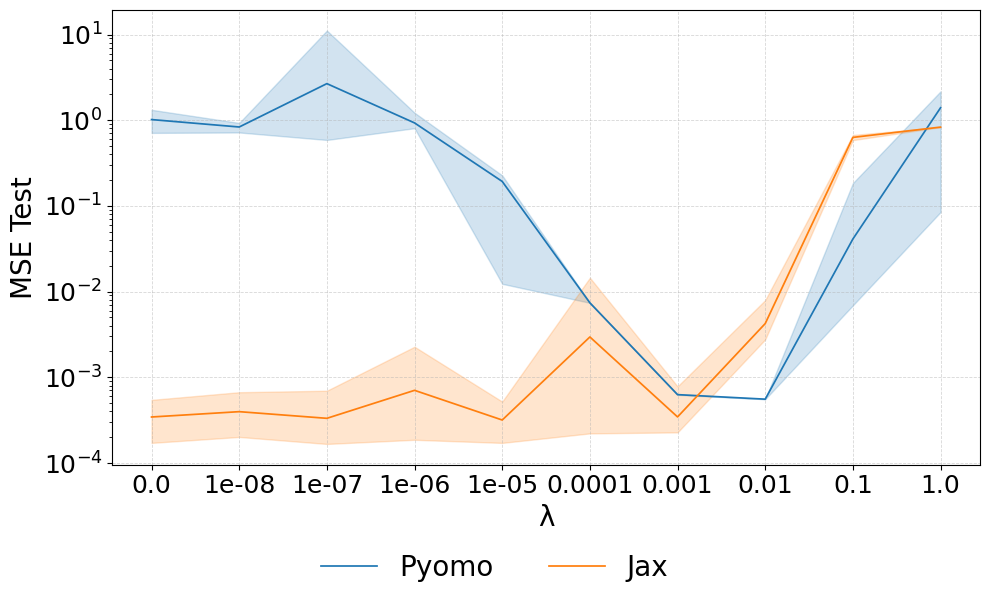

<Axes: xlabel='λ', ylabel='MSE Test'>

In [150]:
Graphs.plot_lines_ci_from_lists(
    pyomo_test_ho['mse_test_coll'],
    jax_test_ho['mse_test'],
    pyomo_test_ho.x_labels,
    title="",
    ylabel="MSE Test",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(5,95),
    alpha_band=0.2,
    line_width=1.25,
    y_log=True,               # default; keeps 10^k ticks
    y_log_locator_base=10,    # default; uses LogLocator
    y_log_mathtext=True,      # default; renders 10^k
    center = 'mean'
)


## Van Der Pole

In [151]:
pyomo_train_vdp.x_labels

0    0.000000e+00
1    1.000000e-08
2    1.000000e-07
3    1.000000e-06
4    1.000000e-05
5    1.000000e-04
6    1.000000e-03
7    1.000000e-02
8    1.000000e-01
9    1.000000e+00
Name: x_labels, dtype: float64

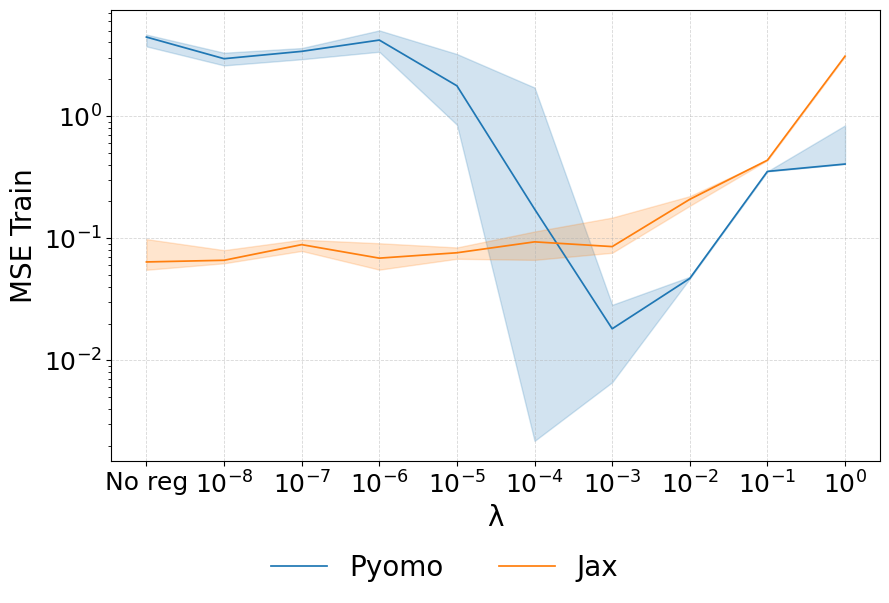

<Axes: xlabel='λ', ylabel='MSE Train'>

In [152]:
exponents = ["No reg", -8, -7, -6, -5, -4, -3, -2, -1, 0] 
x_ticklabels = [fr"$10^{{{p}}}$" if type(p) != str else p for p in exponents]

Graphs.plot_lines_ci_from_lists(
    pyomo_train_vdp['mse_train_coll'],
    jax_train_vdp['mse_train'],
    pyomo_train_vdp.x_labels,
    title="",
    ylabel="MSE Train",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(9, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(20, 80),
    alpha_band=0.2,
    line_width=1.25,
    y_log=True,
    y_log_locator_base=10,
    y_log_mathtext=True,
    x_ticklabels=x_ticklabels,
)


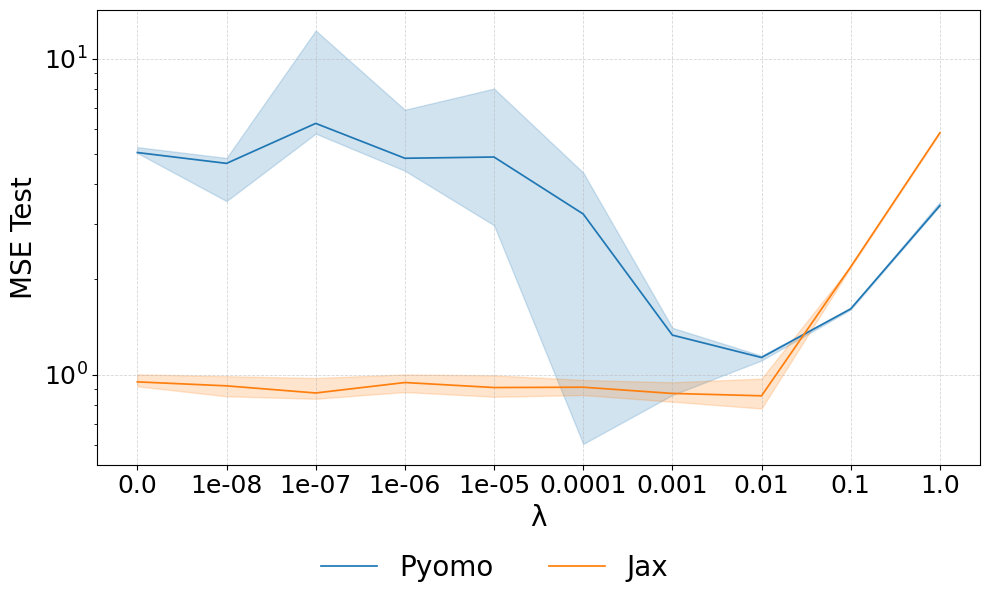

<Axes: xlabel='λ', ylabel='MSE Test'>

In [153]:
Graphs.plot_lines_ci_from_lists(
    pyomo_test_vdp['mse_test_coll'],
    jax_test_vdp['mse_test'],
    pyomo_test_vdp.x_labels,
    title="",
    ylabel="MSE Test",
    color_labels=("Pyomo", "Jax"),
    x_label="λ",
    figsize=(10, 6),
    label_fontsize=20,
    tick_fontsize=18,
    legend_fontsize=20,
    title_fontsize=20,
    legend_bbox_y=-0.02,
    legend_ncol=2,
    ci=(20,80),
    alpha_band=0.2,
    line_width=1.25,
    y_log=True,               # default; keeps 10^k ticks
    y_log_locator_base=10,    # default; uses LogLocator
    y_log_mathtext=True,      # default; renders 10^k
    # center = 'median'
)
